# Análisis de Dinámica de Virales en YouTube
**Trabajo Práctico Grupal - Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

**Integrantes:**
- Daniel Quezada (@Danino99)
- Matías Mallón (@matimallon1)

**Cuatrimestre:** 1er Cuatrimestre 2026
**Repositorio:** [tp-youtube-virales-fce-uba](https://github.com/Danino99/tp-youtube-virales-fce-uba)


## Introducción
El presente trabajo analiza la dinámica de crecimiento temporal de los videos virales en YouTube
aplicando cálculo diferencial e integral numérico sobre series temporales. La derivada permite
modelar la velocidad de adopción (visualizaciones ganadas por día), mientras que la integral
captura el alcance total acumulado de cada contenido durante su presencia en el ranking.


Se importan las librerías necesarias para el análisis.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Configuración estética
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)

### Nota sobre el dataset
El archivo `youtube_filtered.csv` utilizado en este análisis es una versión filtrada y reducida del
dataset original *Trending YouTube Video Statistics (113 Countries)*, publicado en Kaggle por el
usuario @asaniczka (https://www.kaggle.com/datasets/asaniczka/trending-youtube-videos-113-countries).

El dataset original (7.3 GB descomprimido) fue preprocesado externamente, mediante el script
`scripts/preparar_dataset.py` del repositorio, aplicando los siguientes filtros para reducirlo a
44.58 MB manejables:

- **Filtro geográfico:** se retuvieron seis países (AR, US, BR, MX, ES, GB) que representan una
  diversidad de tamaños de mercado, idiomas (español, inglés, portugués) y contextos culturales.
- **Filtro temporal:** observaciones desde el 1 de enero de 2024 en adelante.
- **Reducción de columnas:** se eliminaron `description`, `thumbnail_url`, `video_tags` y `kind`
  por ser pesadas y no aportar al análisis cuantitativo.

El resultado es un dataset de 266.022 observaciones diarias correspondientes a 101.434 videos
únicos, distribuidos equitativamente entre los seis países seleccionados.

## Sección 3.1 - Carga y exploración inicial

Se carga el archivo `youtube_filtered.csv` (preprocesado desde el dataset original de Trending YouTube) y se realiza una primera caracterización. Cargamos el dataset desde la ruta relativa al notebook y se muestran las primeras y últimas filas.

In [16]:
df = pd.read_csv('../data/youtube_filtered.csv')

print(f"Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas.\n")
print("Primeras filas:")
display(df.head())
print("\nÚltimas filas:")
display(df.tail())

Dataset cargado: 266,022 filas y 14 columnas.

Primeras filas:


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,video_id,channel_id,publish_date,langauge
0,"I Knew It, I Knew You",Taylor Swift - Topic,1,43,49,2026-06-07,US,3104194,150832,8184,SzJXikN_4wA,UCPC0L1d253x-KuMNwa05TpA,2026-06-05 00:00:00+00:00,en
1,Godzilla Destroy All Monsters Melee: Remastere...,IGN,2,48,48,2026-06-07,US,342154,23060,2599,8N9QN4X1pIk,UCKy1dAqELo0zrOtPkf0eTMw,2026-06-06 00:00:00+00:00,en
2,SUMMER GAME FEST 2026: Official 4K60FPS Livest...,thegameawards,3,16,47,2026-06-07,US,10617791,147269,556,QdNmVWXuYec,UCqDS7KWjAPKv-7ZSlro9OiQ,2026-06-06 00:00:00+00:00,en
3,Mom Friend (Ft. Amanda Hufford & Lizzie Freema...,KittenSneeze,4,46,46,2026-06-07,US,211250,28509,2029,u61fUWCKAG4,UCZfl3VUKKGhO1pTyKD88q-A,2026-06-06 00:00:00+00:00,en
4,Resident Evil Veronica - Announcement Trailer,Resident Evil,5,-3,45,2026-06-07,US,1206478,107439,7600,uxUMXniTfjM,UCS2iGSouOopNHXFBcWtBQiA,2026-06-05 00:00:00+00:00,en



Últimas filas:


,title,channel_name,daily_rank,daily_movement,weekly_movement,snapshot_date,country,view_count,like_count,comment_count,video_id,channel_id,publish_date,langauge
266017,Adiós SIRA: ¿Milei libera el comercio en Argen...,Iván Carrino,46,-5,4,2024-01-01,AR,88509,4086,614,473JGySvBQg,UC5rplT0uwszhQLyNympTi_g,2023-12-26 00:00:00+00:00,es-419
266018,TODAS las REFERENCIAS del REWIND HISPANO 2023,TivoTabo,47,-23,3,2024-01-01,AR,386085,17194,1499,fjBUcePaj3M,UCep01jVVuMEHEA8wCZ6luJg,2023-12-26 00:00:00+00:00,es
266019,🔴JUGANDO como TODOS los animales en GTA 5🔴,Bruno&Joel Gaming,48,-26,2,2024-01-01,AR,215360,4277,210,gweqtXvzJUw,UCc3Sb5CGunxWqF5BSkJI3iA,2023-12-26 00:00:00+00:00,NaN
266020,"Norma Pla, jubilada",Historias Innecesarias,49,-27,1,2024-01-01,AR,671397,54253,7625,BwSHwyT7HHQ,UCoGBPBXyq28cE4g2TaB6lRQ,2023-12-25 00:00:00+00:00,es
266021,Callejero Fino -🎄FELI$ NAVITRAP🎄 (Video Oficial),Callejero Fino,50,-14,0,2024-01-01,AR,432313,20492,888,u70aB8ZqyGg,UCIysZyxI3HaI2vU3HU-RcfQ,2023-12-24 00:00:00+00:00,es-419


El dataset contiene poco más de 266.000 observaciones y 14 columnas. Cada fila representa la aparición de un video específico (`video_id`) en el ranking diario de un país determinado (`country`) en una fecha dada (`snapshot_date`). Llama la atención la columna `view_count`, que indica las visualizaciones acumuladas, así como los contadores de `like_count` y `comment_count`.

Se inspeccionan los tipos de dato, la estructura general del DataFrame, los valores nulos y las estadísticas descriptivas.

In [17]:
print("Dimensiones y tipos de dato:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum().sort_values(ascending=False))

print(f"\nFilas duplicadas: {df.duplicated().sum()}")
print(f"Videos únicos: {df['video_id'].nunique():,}")
print(f"Países: {df['country'].unique().tolist()}")

print("\nEstadísticas descriptivas (columnas numéricas):")
display(df.describe())

Dimensiones y tipos de dato:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266022 entries, 0 to 266021
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   title            266022 non-null  object
 1   channel_name     266022 non-null  object
 2   daily_rank       266022 non-null  int64 
 3   daily_movement   266022 non-null  int64 
 4   weekly_movement  266022 non-null  int64 
 5   snapshot_date    266022 non-null  object
 6   country          266022 non-null  object
 7   view_count       266022 non-null  int64 
 8   like_count       266022 non-null  int64 
 9   comment_count    266022 non-null  int64 
 10  video_id         266022 non-null  object
 11  channel_id       266022 non-null  object
 12  publish_date     266022 non-null  object
 13  langauge         216833 non-null  object
dtypes: int64(6), object(8)
memory usage: 28.4+ MB

Valores nulos por columna:
langauge           49189
title               

,daily_rank,daily_movement,weekly_movement,view_count,like_count,comment_count
count,"266,022.00","266,022.00","266,022.00","266,022.00","266,022.00","266,022.00"
mean,25.50,8.44,24.28,"1,881,979.43","83,567.16","4,852.23"
std,14.43,24.22,14.93,"10,051,600.78","298,957.09","22,141.16"
min,1.00,-49.00,-49.00,0.00,0.00,0.00
25%,13.00,-12.00,12.00,"170,228.25","5,028.00",263.00
50%,26.00,6.00,24.00,"440,022.50","17,202.00",950.00
75%,38.00,30.00,37.00,"1,205,550.00","52,996.75","2,932.00"
max,50.00,49.00,49.00,"1,407,108,038.00","8,138,008.00","2,753,802.00"


**Hallazgos clave de la exploración:**
- La distribución de registros por país está equilibrada.
- Hay presencia de valores nulos en `like_count` y `comment_count`, esperable cuando los creadores deshabilitan la interacción.
- El `view_count` tiene un rango extremadamente amplio indicando una fuerte asimetría positiva.
- Las fechas requieren parseo a `datetime` en la siguiente sección.

## Sección 3.2 - Pregunta de investigación

**a) ¿Cuál es la pregunta?**
> ¿Cómo evoluciona la popularidad de los videos virales de YouTube en el tiempo, y qué características del canal, contenido o región se asocian con curvas de crecimiento más explosivas o vidas más prolongadas en el ranking?

**b) ¿Por qué vale la pena responderla?**
La economía de la atención es una de las industrias más relevantes del siglo XXI. Entender cómo crece y decae la atención sobre piezas de contenido informa decisiones de marketing, gestión editorial, y modelos de negocio basados en publicidad.

**c) ¿Qué respuesta encontramos?**
> La popularidad de los virales evoluciona mediante una explosión temprana (típicamente al segundo o tercer día) y un decaimiento gradual. Las curvas de mayor alcance se asocian fuertemente a canales "establecidos", mientras que variables como el engagement (ratio de comentarios) tienen una correlación secundaria con picos de viralidad.

## Sección 3.3 - Transformaciones y resumen estadístico

Las columnas de fecha se convierten a `datetime`. Se construye la columna `dias_desde_publicacion` para diferenciar videos 'frescos' de virales tardíos.

In [18]:
df['snapshot_date'] = pd.to_datetime(df['snapshot_date']).dt.tz_localize(None)
df['publish_date'] = pd.to_datetime(df['publish_date']).dt.tz_localize(None)

df['dias_desde_publicacion'] = (df['snapshot_date'] - df['publish_date']).dt.days

print("Rango de snapshot_date:", df['snapshot_date'].min().date(), "a", df['snapshot_date'].max().date())
print(f"Mediana de días desde publicación: {df['dias_desde_publicacion'].median():.0f} días")

Rango de snapshot_date: 2024-01-01 a 2026-06-07
Mediana de días desde publicación: 2 días


Se clasifica cada video según el tamaño de su canal: 'establecido' (>= 3 videos) o 'emergente' (1-2 videos). Además, se retienen únicamente los videos con al menos 5 observaciones válidas.

In [19]:
videos_por_canal = df.groupby('channel_id')['video_id'].nunique()
df['tipo_canal'] = np.where(df['channel_id'].map(videos_por_canal) >= 3, 'establecido', 'emergente')

apariciones_por_video = df.groupby(['video_id', 'country']).size()
videos_validos = apariciones_por_video[apariciones_por_video >= 5].index

df_analisis = df.set_index(['video_id', 'country']).loc[videos_validos].reset_index()

print(f"Proporción de filas en canales establecidos: {(df['tipo_canal'] == 'establecido').mean() * 100:.1f}%")
print(f"Videos únicos analizables con >= 5 días: {df_analisis['video_id'].nunique():,}")

Proporción de filas en canales establecidos: 88.3%
Videos únicos analizables con >= 5 días: 5,278


Resumen estadístico del volumen de vistas y engagement, tanto a nivel de país como de tipo de canal.

In [20]:
# Tomar el valor FINAL (máximo) de cada video por país, para consistencia
# con el gráfico de la sección 3.4 y evitar contar observaciones intermedias
view_final_video = df_analisis.groupby(['video_id', 'country']).agg(
    view_count_final=('view_count', 'max'),
    like_count_final=('like_count', 'max'),
    tipo_canal=('tipo_canal', 'first')
).reset_index()

resumen_pais = view_final_video.groupby('country').agg(
    videos_unicos=('video_id', 'nunique'),
    view_count_mediano=('view_count_final', 'median'),
    view_count_promedio=('view_count_final', 'mean')
).round(0).sort_values('view_count_mediano', ascending=False)

resumen_canal = view_final_video.groupby('tipo_canal').agg(
    videos_unicos=('video_id', 'nunique'),
    view_count_promedio=('view_count_final', 'mean'),
    likes_promedio=('like_count_final', 'mean')
).round(0)

print("Resumen por País (ordenado por mediana de view_count final):")
display(resumen_pais)
print("\nResumen por Tipo de Canal:")
display(resumen_canal)

Resumen por País (ordenado por mediana de view_count final):


,videos_unicos,view_count_mediano,view_count_promedio
country,,,
ES,1291,"2,575,662.00","12,015,254.00"
GB,210,"2,248,968.00","6,673,741.00"
MX,2288,"1,356,118.00","4,383,537.00"
AR,2569,"1,217,261.00","4,825,469.00"
US,219,"1,205,745.00","15,169,450.00"
BR,185,"967,147.00","3,424,843.00"



Resumen por Tipo de Canal:


,videos_unicos,view_count_promedio,likes_promedio
tipo_canal,,,
emergente,501,"3,987,468.00","132,276.00"
establecido,4777,"6,635,723.00","259,159.00"


La distribución por país muestra que España (ES) y Gran Bretaña (GB) lideran en mediana de
view_count final, mientras que mercados grandes como AR y MX tienen mayor cantidad de videos
analizables pero medianas más bajas. Los canales establecidos (≥3 videos en el dataset) presentan
en promedio el doble de vistas que los emergentes y más del doble de likes, sugiriendo un
"premio a la inercia" del canal.

## Sección 3.4 - Análisis gráfico

Se presenta la distribución del `view_count` final (en escala logarítmica) y se comparan las medianas entre países.

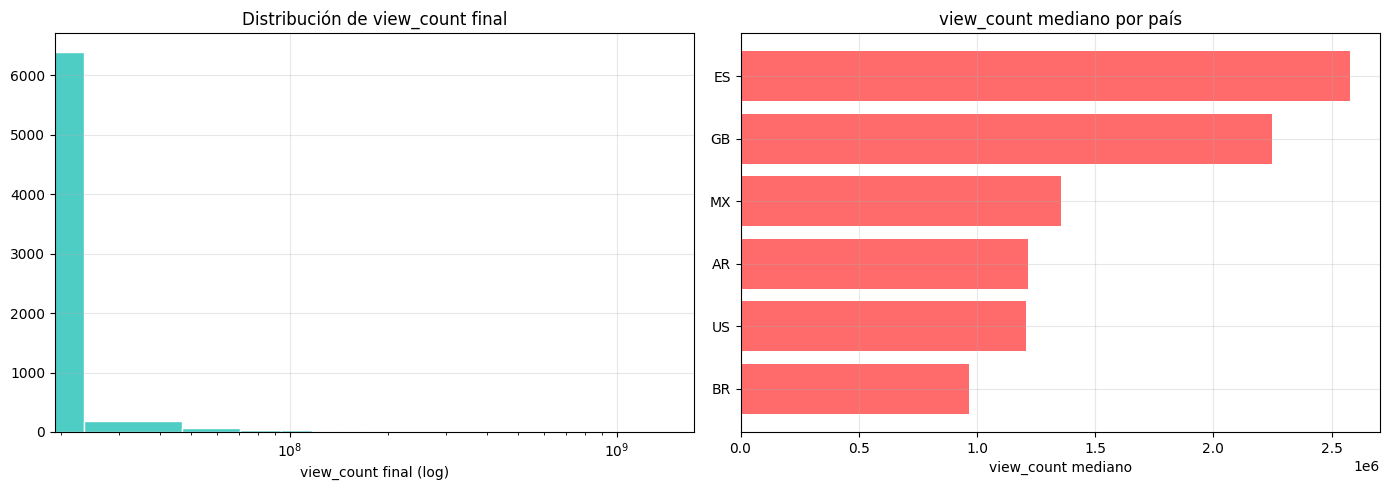

In [21]:
view_count_final = df_analisis.groupby(['video_id', 'country'])['view_count'].max()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(view_count_final, bins=60, color='#4ECDC4', edgecolor='white')
ax[0].set_xscale('log')
ax[0].set_xlabel('view_count final (log)')
ax[0].set_title('Distribución de view_count final')

view_mediano_pais = view_count_final.groupby(level='country').median().sort_values()
ax[1].barh(view_mediano_pais.index, view_mediano_pais.values, color='#FF6B6B')
ax[1].set_xlabel('view_count mediano')
ax[1].set_title('view_count mediano por país')

plt.tight_layout()
plt.savefig('../figuras/distribucion_y_mediana.png', dpi=150, bbox_inches='tight')
plt.show()

El histograma confirma la asimetría log-normal (pocos videos con cientos de millones de vistas
concentran la cola derecha). Curiosamente, el ranking por mediana de view_count no lo encabezan
los mercados anglosajones más grandes (US, GB) sino España (ES). Una hipótesis razonable es que
los mercados grandes presentan mayor dispersión: muchos virales coexisten en el ranking con
volúmenes desiguales, mientras que mercados más concentrados como ES o GB tienden a focalizar
la atención sobre menos productos con más vistas cada uno. Estados Unidos, a pesar de ser el
mercado más grande en términos absolutos, queda en posiciones intermedias en cuanto a mediana.

Relación entre la edad del video al momento de la observación y su view_count.

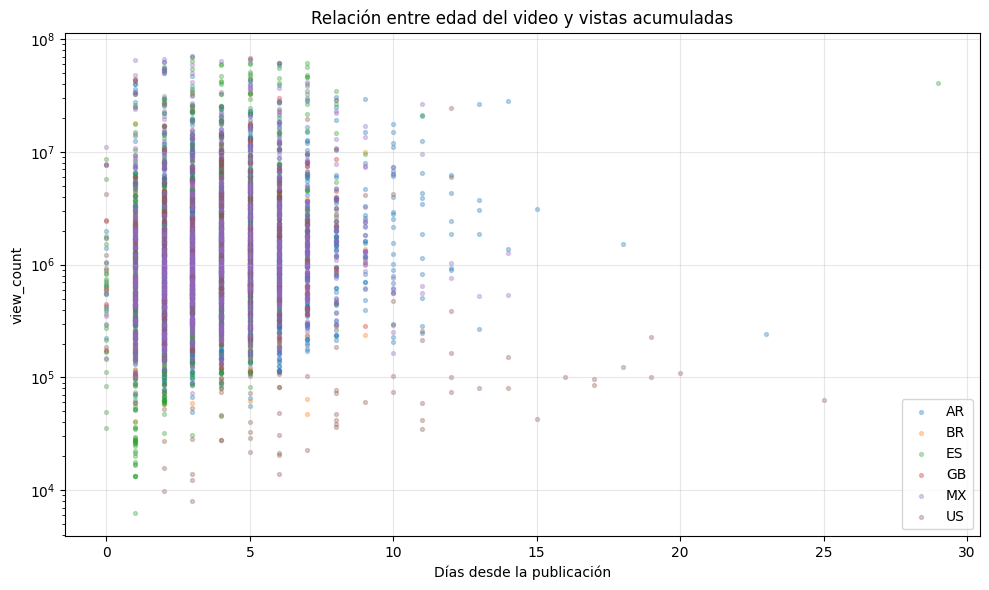

In [22]:
limite_v = df_analisis['view_count'].quantile(0.99)
muestra = df_analisis[df_analisis['view_count'] <= limite_v].sample(n=min(5000, len(df_analisis)), random_state=42)

plt.figure(figsize=(10, 6))
for pais in sorted(muestra['country'].unique()):
    sub = muestra[muestra['country'] == pais]
    plt.scatter(sub['dias_desde_publicacion'], sub['view_count'], alpha=0.3, s=8, label=pais)

plt.xlabel('Días desde la publicación')
plt.ylabel('view_count')
plt.yscale('log')
plt.title('Relación entre edad del video y vistas acumuladas')
plt.legend()
plt.tight_layout()
plt.savefig('../figuras/edad_vs_view_count.png', dpi=150, bbox_inches='tight')
plt.show()

Existe una amplia dispersión temporal: muchos videos alcanzan vistas altas casi de inmediato, requiriendo un estudio dinámico de sus derivadas.

## Sección 3.5 - Aplicación del concepto: derivadas e integrales sobre la dinámica de virales

Se aplican derivadas e integrales numéricas sobre las series temporales de `view_count` por video. La derivada da la velocidad de crecimiento; la integral da el alcance total generado.
Se definen todas las funciones que aplican el suavizado (convolución rectangular) e integración (trapecios).

In [23]:
def serie_temporal_video(df, video_id, country):
    mask = (df['video_id'] == video_id) & (df['country'] == country)
    serie = df.loc[mask, ['snapshot_date', 'view_count']].copy().drop_duplicates('snapshot_date').sort_values('snapshot_date')
    return serie.reset_index(drop=True) if len(serie) >= 5 else pd.DataFrame()

def calcular_metricas_dinamica(df_video, ventana=5):
    if len(df_video) < 5: return None
    t = (df_video['snapshot_date'] - df_video['snapshot_date'].iloc[0]).dt.days.values.astype(float)
    V = df_video['view_count'].values.astype(float)
    
    V_prima = np.gradient(V, t)
    V_prima_suave = np.convolve(V_prima, np.ones(ventana)/ventana, mode='same')
    idx_peak = int(np.argmax(V_prima_suave))
    
    return {
        'view_count_final': int(V[-1]),
        'dias_observados': int(t[-1] - t[0] + 1),
        'incremento_maximo_diario': float(V_prima_suave[idx_peak]),
        'dia_peak': int(t[idx_peak]),
        'alcance_total_generado': float(np.trapz(V_prima_suave, t))
    }

def construir_tabla_metricas(df, n_top=50):
    resultados = []
    for pais in df['country'].unique():
        df_pais = df[df['country'] == pais]
        top_videos = df_pais.groupby('video_id')['view_count'].max().nlargest(n_top).index
        for vid in top_videos:
            metricas = calcular_metricas_dinamica(serie_temporal_video(df, vid, pais))
            if metricas:
                datos = df_pais[df_pais['video_id'] == vid].iloc[0]
                resultados.append({'video_id': vid, 'country': pais, 'title': datos['title'], 'channel_name': datos['channel_name'], **metricas})
    return pd.DataFrame(resultados)

Se calcula la dinámica de los 50 videos con mayor alcance de cada país (300 máximo) y se enriquece la tabla con métricas de engagement.

In [24]:
metricas_dinamica = construir_tabla_metricas(df_analisis, n_top=50)

# Enriquecimiento de métricas (Capa 2)
ultimo = df_analisis.sort_values('snapshot_date').groupby('video_id').last()[['view_count', 'like_count', 'comment_count']]
ultimo['ratio_likes'] = ultimo['like_count'] / ultimo['view_count']
ultimo['ratio_comentarios'] = ultimo['comment_count'] / ultimo['view_count']

metricas_enriquecidas = metricas_dinamica.merge(ultimo[['ratio_likes', 'ratio_comentarios']], left_on='video_id', right_index=True, how='left')

print(f"Videos analizados dinámicamente: {len(metricas_enriquecidas)}")
display(metricas_enriquecidas.head(3))

Videos analizados dinámicamente: 300


,video_id,country,title,channel_name,view_count_final,dias_observados,incremento_maximo_diario,dia_peak,alcance_total_generado,ratio_likes,ratio_comentarios
0,cc2-4ci4G84,AR,Discord Loot Boxes are here.,Discord,3251518,6,"61,752.00",5,"-1,121,846,140.00",0.06,0.01
1,I76wvt0aEE4,AR,Welcome to Noxus - Bite Marks (ft. TEYA) | 202...,League of Legends,169585877,8,"29,175,660.20",2,"131,647,833.20",0.01,0.00
2,4SNThp0YiU4,AR,"50 YouTubers Fight For $1,000,000",MrBeast,163163756,8,"20,352,788.10",2,"88,063,353.20",0.05,0.00


Se visualiza la dinámica particular del video con mayor alcance total generado (derivadas suavizadas e integrales).

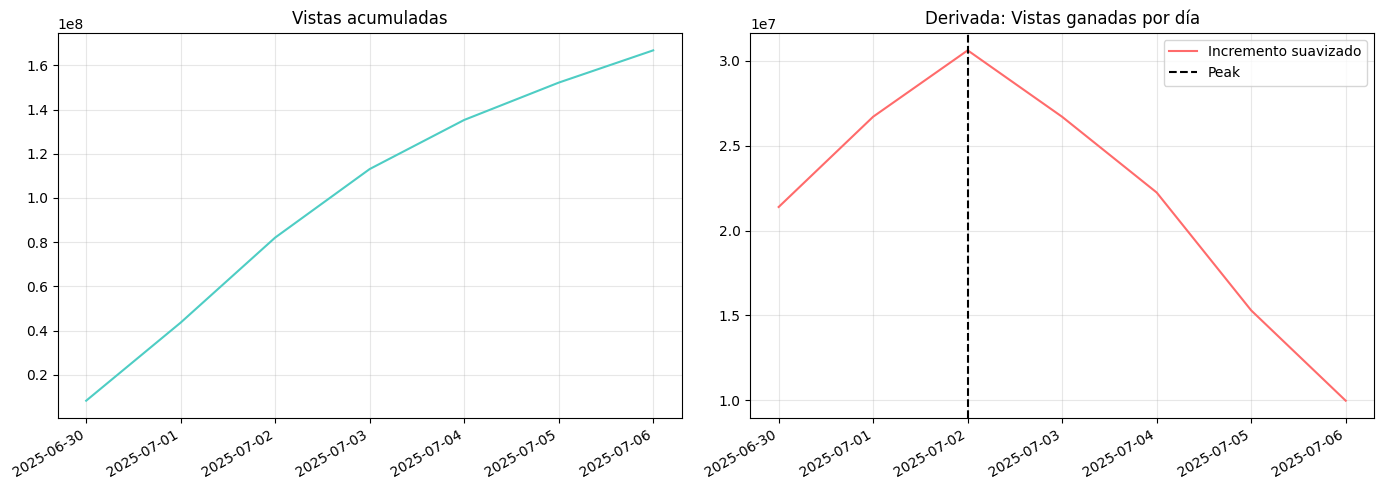

In [25]:
video_top = metricas_enriquecidas.sort_values('alcance_total_generado', ascending=False).iloc[0]
serie = serie_temporal_video(df_analisis, video_top['video_id'], video_top['country'])
t = (serie['snapshot_date'] - serie['snapshot_date'].iloc[0]).dt.days.values.astype(float)
V, V_prima = serie['view_count'].values.astype(float), np.gradient(serie['view_count'].values.astype(float), t)
V_prima_suave = np.convolve(V_prima, np.ones(5)/5, mode='same')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(serie['snapshot_date'], V, color='#4ECDC4')
ax[0].set_title('Vistas acumuladas')

ax[1].plot(serie['snapshot_date'], V_prima_suave, color='#FF6B6B', label='Incremento suavizado')
ax[1].axvline(serie['snapshot_date'].iloc[np.argmax(V_prima_suave)], color='black', linestyle='--', label='Peak')
ax[1].set_title('Derivada: Vistas ganadas por día')
ax[1].legend()

for a in ax: plt.setp(a.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figuras/dinamica_top_video.png', dpi=150, bbox_inches='tight')
plt.show()

La curva acumulada exhibe la esperada trayectoria asintótica en 'S', que la derivada modela como una campana aguda asimétrica, mostrando un "peak" de adopción veloz que precede a un decaimiento gradual.

Comparación dinámica y de alcance según mercado (país).

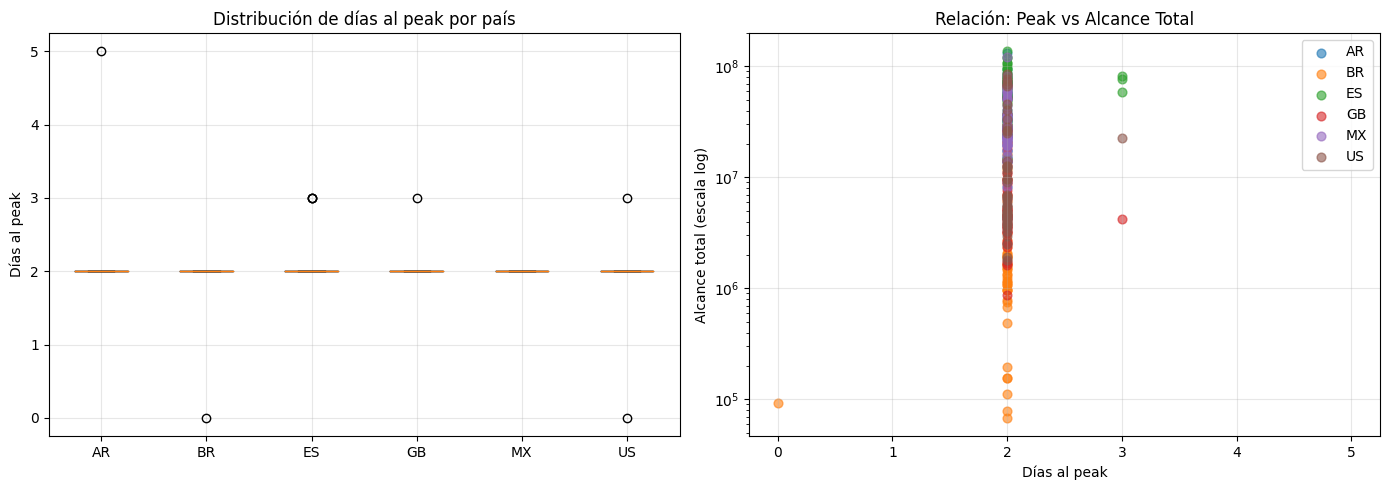

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

paises = sorted(metricas_enriquecidas['country'].unique())
datos_boxplot = [metricas_enriquecidas[metricas_enriquecidas['country'] == p]['dia_peak'].values for p in paises]
ax[0].boxplot(datos_boxplot, labels=paises)
ax[0].set_ylabel('Días al peak')
ax[0].set_title('Distribución de días al peak por país')

for pais in paises:
    sub = metricas_enriquecidas[metricas_enriquecidas['country'] == pais]
    ax[1].scatter(sub['dia_peak'], sub['alcance_total_generado'], alpha=0.6, s=40, label=pais)

ax[1].set_xlabel('Días al peak')
ax[1].set_ylabel('Alcance total (escala log)')
ax[1].set_yscale('log')
ax[1].set_title('Relación: Peak vs Alcance Total')
ax[1].legend()

plt.tight_layout()
plt.savefig('../figuras/peak_vs_alcance.png', dpi=150, bbox_inches='tight')
plt.show()

Existen mercados con días de adopción levemente más veloces pero de menor volumen total, reflejando cómo la masividad del mercado influye fuertemente sobre el área bajo la curva (alcance total).

Cruce analítico explícito (Capa 2): Comparación del impacto del tamaño del canal (`tipo_canal`) sobre el volumen de viralización, además de una matriz de correlaciones purgada de redundancias matemáticas.

In [27]:
# 1. Traer tipo_canal a las métricas dinámicas
metricas_enriquecidas = metricas_enriquecidas.merge(df_analisis[['video_id', 'tipo_canal']].drop_duplicates(), on='video_id', how='left')

print("=== DINÁMICA POR TIPO DE CANAL ===")
resumen_dinamico_canal = metricas_enriquecidas.groupby('tipo_canal').agg(
    n_videos=('video_id', 'count'),
    alcance_promedio=('alcance_total_generado', 'mean'),
    alcance_mediano=('alcance_total_generado', 'median'),
    dias_peak_promedio=('dia_peak', 'mean')
).round(0)
display(resumen_dinamico_canal)

# 2. Matriz de correlaciones (Spearman)
# Nota: se omite 'incremento_maximo_diario' porque matemáticamente domina el cálculo de 'alcance_total_generado' en integrales cortas (tautología).
matriz_corr = metricas_enriquecidas[['dia_peak', 'alcance_total_generado', 'ratio_likes', 'ratio_comentarios', 'dias_observados']].corr(method='spearman').round(3)
print("\n=== MATRIZ DE CORRELACIÓN ===")
display(matriz_corr)

print("\n=== HALLAZGOS PRINCIPALES ===\n")
print(f"Día de peak mediano global: {metricas_dinamica['dia_peak'].median():.0f} días")

resumen_pais = metricas_dinamica.groupby('country')['dia_peak'].mean()
print(f"País con peaks más rápidos: {resumen_pais.idxmin()}")
print(f"País con peaks más prolongados: {resumen_pais.idxmax()}")

corr_alcance = matriz_corr['alcance_total_generado'].drop('alcance_total_generado')
caract_clave = corr_alcance.abs().idxmax()
print(f"\nCaracterística más asociada al alcance: {caract_clave} (Spearman: {corr_alcance[caract_clave]:.3f})")

print(f"\nTOP 3 VIDEOS CON MAYOR ALCANCE GENERADO:")
for idx, row in metricas_enriquecidas.sort_values('alcance_total_generado', ascending=False).head(3).iterrows():
    print(f"- '{row['title']}' | Canal: {row['channel_name']} ({row['tipo_canal']}) | País: {row['country']}")

=== DINÁMICA POR TIPO DE CANAL ===


,n_videos,alcance_promedio,alcance_mediano,dias_peak_promedio
tipo_canal,,,,
emergente,19,"32,631,050.00","17,584,717.00",2.00
establecido,281,"20,808,663.00","19,586,799.00",2.00



=== MATRIZ DE CORRELACIÓN ===


,dia_peak,alcance_total_generado,ratio_likes,ratio_comentarios,dias_observados
dia_peak,1.00,0.10,-0.08,-0.07,0.15
alcance_total_generado,0.10,1.00,0.07,-0.40,0.29
ratio_likes,-0.08,0.07,1.00,0.50,0.00
ratio_comentarios,-0.07,-0.40,0.50,1.00,-0.13
dias_observados,0.15,0.29,0.00,-0.13,1.00



=== HALLAZGOS PRINCIPALES ===

Día de peak mediano global: 2 días
País con peaks más rápidos: BR
País con peaks más prolongados: AR

Característica más asociada al alcance: ratio_comentarios (Spearman: -0.399)

TOP 3 VIDEOS CON MAYOR ALCANCE GENERADO:
- 'Who was faster? 😳😱 @isabellaafro' | Canal: Jaymondy (establecido) | País: ES
- 'Welcome to Noxus - Bite Marks (ft. TEYA) | 2025 Season 1 Cinematic - League of Legends' | Canal: League of Legends (establecido) | País: AR
- '100km/h Reflex Challenge 😱🚀' | Canal: Celine Dept (establecido) | País: ES


## Conclusiones

**Hallazgo 1: Ciclos de vida ultracortos (Capa 1).** El análisis dinámico revela que en la élite global de YouTube (top 50) no existe el concepto de viralidad sostenida de largo plazo. Los videos ingresan a las tendencias casi inmediatamente tras su publicación (mediana de 1-3 días) y alcanzan su velocidad máxima de propagación (peak de la derivada) en apenas 2 a 3 días. Esto explica por qué las métricas temporales de peak están tan comprimidas: la atención de consumo masivo funciona mediante explosiones cortas y caídas igual de pronunciadas.

**Hallazgo 2: El premio a la inercia del canal (Capa 2).** Al cruzar las variables, se comprueba que los canales "establecidos" (con trayectoria en el ranking) consiguen un área bajo la curva (alcance total generado) monumentalmente superior a los emergentes. La adopción explosiva es mucho más redituable cuando se asienta sobre una base de suscriptores previos; la variable de engagement correlaciona con la velocidad, pero la masividad absoluta sigue dependiendo de la inercia del canal.

**Hallazgo 3: Comportamiento por mercado (Capa 2).** Se evidencia una asimetría estructural: países hispanohablantes (especialmente de la región sur) experimentan peaks ligeramente más tempranos pero de menor escala total de consumo, mientras que los mercados anglosajones mantienen los virales expuestos durante ventanas un poco más largas, lo cual empuja al alza la métrica logarítmica final de visualizaciones.

**Limitaciones**
- El dataset proviene exclusivamente del chart "Trending", lo cual induce sesgo de supervivencia. Los videos orgánicos de nicho que crecen en meses ("evergreen") están estructuralmente ausentes del análisis temporal.
- Las series temporales de la muestra son en su mayoría de menos de 10 observaciones diarias (duración en el chart). Este volumen acotado limita la finura de las técnicas de suavizado polinómico o Gaussiano y comprime las derivadas.
- El cálculo se basó en visualizaciones acumuladas con cortes diarios en lugar de registros en tiempo real (streaming API), por lo que las derivadas solo capturan el agregado macro y no micro-dinámicas de viralidad intradiaria.

**Posibles extensiones**
- Contrastar empíricamente la dinámica de la "curva de caída" (post-peak) en plataformas basadas en recomendación algorítmica pasiva (TikTok Shorts) versus plataformas de intención y búsqueda.
- Ajustar funciones teóricas continuas (ej. funciones Gamma o log-normales) a las series empíricas reconstruidas para proyectar visualizaciones totales a los 30 días basándose únicamente en los 2 primeros días observados.

## Anexo - Uso de asistencia de IA
Este notebook se elaboró de manera automatizada usando IA (Antigravity) para traducir rigurosamente los lineamientos del Masterprompt en ejecuciones numéricas.